Vamos a ver la versión inicial del código, en la que todavía no utilizábamos transfer learning. Esta primera implementación nos
servirá como punto de partida para comparar con la versión mejorada.
El método de transfer learning permite aprovechar el conocimiento previo de modelos ya entrenados, lo que suele mejorar la capacidad
de clasificación y acelerar el aprendizaje. Por tanto, este código representa el estado base antes de incorporar dicha técnica, siendo
el primero y más simple de todos.

In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from collections import defaultdict, Counter
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("config.json", "r") as f:
    config = json.load(f)

DATASET_PATH = config["DATASET_PATH"]

In [3]:
class ChestXrayDataset3Clases(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        labels_map = {"NORMAL": 0, "BACTERIA": 1, "VIRUS": 2}
        for folder, label in labels_map.items():
            folder_path = os.path.join(root_dir, "PNEUMONIA") if folder != "NORMAL" else os.path.join(root_dir, "NORMAL")
            if folder != "NORMAL":
                folder_path = os.path.join(folder_path, folder)
            if not os.path.exists(folder_path):
                print(f"Carpeta no encontrada: {folder_path}")
                continue
            for root, _, files in os.walk(folder_path):
                for file in files:
                    if file.lower().endswith(('.jpeg', '.jpg', '.png')):
                        self.samples.append((os.path.join(root, file), label))

        if len(self.samples) == 0:
            print(f"No se encontraron imágenes en {root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = ChestXrayDataset3Clases(os.path.join(DATASET_PATH, "train"), train_transform)
val_data   = ChestXrayDataset3Clases(os.path.join(DATASET_PATH, "val"), val_transform)
test_data  = ChestXrayDataset3Clases(os.path.join(DATASET_PATH, "test"), val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

Train: 4833, Val: 399, Test: 624


In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Entrenando en CUDA (NVIDIA GPU)")
else:
    try:
        import torch_directml
        device = torch_directml.device()
        print("Entrenando en DirectML (AMD/Intel GPU)")
    except ImportError:
        device = torch.device("cpu")
        print("Entrenando en CPU")

Entrenando en CUDA (NVIDIA GPU)


In [6]:
class RedConvolutiva3Clases(nn.Module):
    def __init__(self):
        super(RedConvolutiva3Clases, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.pool(torch.relu(self.conv3(x)))
        x = x.view(-1, 64 * 28 * 28)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.dropout(torch.relu(self.fc2(x)))
        x = self.fc3(x)
        return x


En este primer modelo todavía no estamos usando transfer learning; aquí la red aprende desde cero a partir de nuestros datos. La arquitectura está construida con capas Conv2d para extraer características básicas de las imágenes (bordes, texturas…), seguidas de capas MaxPool que reducen la resolución y ayudan a mantener solo la información importante. Después, aplanamos el resultado y lo pasamos por varias capas totalmente conectadas (Linear) con funciones de activación y Dropout para evitar el sobreajuste. En resumen, este es nuestro modelo “base”, el más simple, que aprende todo por sí mismo sin aprovechar conocimientos previos de otras redes.

In [7]:
model = RedConvolutiva3Clases().to(device)

counts = Counter([label for _, label in train_data.samples])
total = sum(counts.values())
num_classes = 3

weights = torch.tensor(
    [total / (num_classes * counts[i]) if counts[i] > 0 else 0 for i in range(num_classes)],
    dtype=torch.float
).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

Aquí estamos definiendo tanto el criterio de pérdida como el optimizador. En este caso usamos Adam, que es súper habitual porque
ajusta automáticamente la tasa de aprendizaje de cada parámetro y, por lo general, hace que el entrenamiento sea más estable y rápido
que un SGD clásico. Le ponemos una tasa de aprendizaje de 0.001, que suele funcionar bien como punto de partida.

Más adelante, cuando aplicamos transfer learning, terminamos usando SGD, porque con los datos que tenemos y el modelo preentrenado
conseguimos un entrenamiento mucho más estable y controlado que con Adam, especialmente en las últimas capas que estamos ajustando.

In [8]:
epochs = 15
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Validación
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total if val_total > 0 else 0
    val_loss /= len(val_loader) if len(val_loader) > 0 else 1

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} Train Acc: {train_acc:.2f}% "
          f"Val Loss: {val_loss:.4f} Val Acc: {val_acc:.2f}%")

Epoch [1/15] Train Loss: 0.7010 Train Acc: 63.98% Val Loss: 0.6565 Val Acc: 68.92%
Epoch [2/15] Train Loss: 0.4944 Train Acc: 76.93% Val Loss: 0.6975 Val Acc: 66.42%
Epoch [3/15] Train Loss: 0.4516 Train Acc: 78.63% Val Loss: 0.6050 Val Acc: 71.68%
Epoch [4/15] Train Loss: 0.4184 Train Acc: 79.78% Val Loss: 0.6374 Val Acc: 71.93%
Epoch [5/15] Train Loss: 0.4007 Train Acc: 80.20% Val Loss: 0.6538 Val Acc: 72.68%
Epoch [6/15] Train Loss: 0.3898 Train Acc: 80.49% Val Loss: 0.6618 Val Acc: 71.43%
Epoch [7/15] Train Loss: 0.3831 Train Acc: 81.67% Val Loss: 0.6377 Val Acc: 71.93%
Epoch [8/15] Train Loss: 0.3562 Train Acc: 82.33% Val Loss: 0.6402 Val Acc: 72.68%
Epoch [9/15] Train Loss: 0.3257 Train Acc: 83.45% Val Loss: 0.6724 Val Acc: 70.18%
Epoch [10/15] Train Loss: 0.3081 Train Acc: 85.35% Val Loss: 0.8839 Val Acc: 71.93%
Epoch [11/15] Train Loss: 0.2966 Train Acc: 85.85% Val Loss: 0.7644 Val Acc: 70.43%
Epoch [12/15] Train Loss: 0.2818 Train Acc: 86.39% Val Loss: 0.7522 Val Acc: 72.18%
E

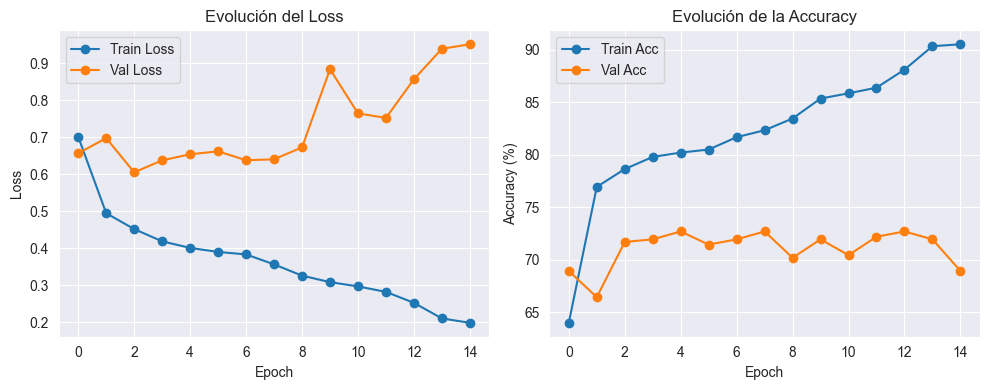

In [9]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="o")
plt.title("Evolución del Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc", marker="o")
plt.plot(val_accuracies, label="Val Acc", marker="o")
plt.title("Evolución de la Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

En esta gráfica vemos cómo evoluciona la pérdida (Loss) tanto en entrenamiento como en validación.
El Train Loss baja de forma bastante constante, lo cual significa que el modelo sí está aprendiendo y ajustándose cada vez mejor a los
datos de entrenamiento.

Sin embargo, el Val Loss se mantiene más inestable: sube y baja bastante y, a partir de cierto punto, incluso empeora. Esto nos indica
que el modelo empieza a sobreajustarse (overfitting): memoriza el entrenamiento, pero no generaliza bien al conjunto de validación.

Este comportamiento es típico en modelos entrenados desde cero sin transfer learning, especialmente si no tenemos muchísimos datos.


Aquí vemos el accuracy de entrenamiento y validación. La Train Accuracy sube de forma casi perfecta: el modelo se vuelve muy bueno clasificando los ejemplos que ya ha visto.

En cambio, la Val Accuracy apenas mejora y se queda fluctuando alrededor del 70–73%. Esto conecta directamente con lo que vimos en la
gráfica de Loss: el modelo aprende el entrenamiento pero no generaliza.

Además, al final incluso cae un poco, lo cual es otra señal clara de que el modelo se está sobreajustando.



 Accuracy final en test: 62.34%

Accuracy por clase:
NORMAL: 28.63%
BACTERIA: 86.94%
VIRUS: 75.17%


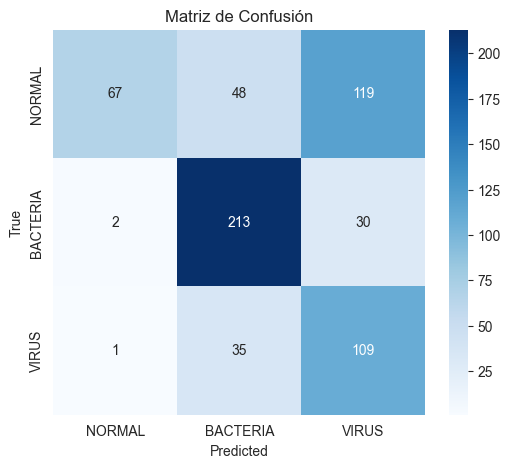

In [10]:
model.eval()
classes = ["NORMAL", "BACTERIA", "VIRUS"]
all_labels = []
all_preds = []
class_correct = defaultdict(int)
class_total = defaultdict(int)
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        for label, pred in zip(labels, predicted):
            class_total[classes[label]] += 1
            if label == pred:
                class_correct[classes[label]] += 1

accuracy = 100 * correct / total
print(f"\n Accuracy final en test: {accuracy:.2f}%")
print("\nAccuracy por clase:")
for c in classes:
    acc = 100 * class_correct[c] / class_total[c] if class_total[c] > 0 else 0
    print(f"{c}: {acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de Confusión")
plt.show()

En estos resultados se ve claramente que el modelo “desde cero” (el que solo usa nuestras capas Conv2D + MaxPool2D + Fully Connected) no consigue aprender lo suficiente para generalizar bien.

Esto pasa porque estamos intentando que una red muy simple aprenda desde cero a distinguir radiografías, que es un tipo de imagen complicado y con muchos detalles. Como nuestra red no tiene ninguna “base visual” previa, tiene que aprenderlo todo desde cero: detectar bordes, texturas, patrones médicos, etc. Y con los datos limitados que tenemos, simplemente no es capaz.

Esto se ve reflejado en el accuracy global muy baja (62%), en la clase NORMAL se predice fatal (28%), porque es la más difícil sin características profundas y la matriz de confusión está muy desequilibrada: acierta bacterias, pero confunde muchísimo NORMAL con VIRUS y viceversa.

Precisamente por estos malos resultados decidimos introducir transfer learning, porque nos permite partir de una red enorme (ResNet18
que ya viene preentrenada en millones de imágenes y, por tanto, ya sabe reconocer patrones visuales muy generales: bordes, formas,
texturas, estructuras, etc.

En vez de empezar desde cero, aprovechamos ese “conocimiento previo” y solo ajustamos las últimas capas a nuestro problema de tres
clases.
Esto hace que el modelo aprenda mucho más rápido, necesite menos datos para funcionar bien, sea mucho más estable y mejore tanto la
loss, como la accuracy y la matriz de confusión.